# Projet 13 - Analyse des Résultats Random Search

Ce notebook charge et analyse les résultats du Random Search

In [1]:
import sys
sys.path.insert(0, '..')

import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from src import utils

c:\Users\DELL\anaconda3\envs\mlop\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Charger les résultats JSON

In [ ]:
# Trouver le fichier JSON le plus récent
results_dir = Path('C:/Users/DELL/Documents/Rapports/projet_transformers/outputs/results')
json_files = list(results_dir.glob('optimization_results_*.json'))

if json_files:
    latest_json = sorted(json_files)[-1]
    print(f"Fichier JSON trouvé: {latest_json}")
    
    with open(latest_json, 'r') as f:
        results_data = json.load(f)
    
    print(f"\nConfiguration du Random Search:")
    for key, val in results_data['config'].items():
        print(f"  {key}: {val}")
else:
    print(" Aucun fichier de résultats trouvé! Lancez d'abord src/random_search.py")

Fichier JSON trouvé: C:\Users\DELL\Documents\Rapports\projet_transformers\outputs\results\optimization_results_20260303_150759.json

Configuration du Random Search:
  train_subset_size: 10000
  val_size: 2000
  batch_size: 32
  max_steps: 200
  eval_steps: 25
  patience: 5
  num_classes: 6


## Créer un DataFrame des résultats

In [3]:
if 'results_data' in locals():
    results = results_data['results']
    
    # Créer une liste de dictionnaires
    data = []
    for result in results:
        data.append({
            'Optimizer': result['optimizer'],
            'Learning Rate': result['learning_rate'],
            'Final Loss': result['final_val_loss'],
            'Final Accuracy': result['final_accuracy'],
            'Final F1-macro': result['final_f1_macro'],
            'Total Steps': result['total_steps']
        })
    
    df = pd.DataFrame(data)
    
    # Ajouter un classement
    df['Accuracy Rank'] = df['Final Accuracy'].rank(ascending=False).astype(int)
    
    # Trier par accuracy
    df = df.sort_values('Final Accuracy', ascending=False).reset_index(drop=True)
    
    print("Résultats finaux de toutes les configurations:\n")
    print(df.to_string(index=False))

Résultats finaux de toutes les configurations:

Optimizer  Learning Rate  Final Loss  Final Accuracy  Final F1-macro  Total Steps  Accuracy Rank
      SGD        0.00010    1.155011          0.9350        0.926567          200              1
      SGD        0.00100    0.247427          0.9290        0.924303          200              2
    AdamW        0.00010    0.438069          0.9230        0.915815          200              3
    AdamW        0.00001    1.445350          0.9110        0.905470          200              4
    AdamW        0.00100    0.342830          0.8820        0.871487          200              5
Adafactor        0.00100    1.466014          0.8280        0.750216          200              6
Adafactor        0.00001    1.538198          0.7540        0.629304          200              7
Adafactor        0.00010    1.514576          0.7370        0.730325          200              8
      SGD        0.00001    1.623541          0.6035        0.586085          2

## Statistiques par optimiseur

In [4]:
if 'df' in locals():
    print("\nStatistiques par optimiseur:\n")
    
    for optimizer in df['Optimizer'].unique():
        subset = df[df['Optimizer'] == optimizer]
        print(f"\n{optimizer}:")
        print(f"  Accuracy moyenne: {subset['Final Accuracy'].mean():.4f}")
        print(f"  Accuracy max: {subset['Final Accuracy'].max():.4f}")
        print(f"  Accuracy min: {subset['Final Accuracy'].min():.4f}")
        print(f"  F1-macro moyenne: {subset['Final F1-macro'].mean():.4f}")


Statistiques par optimiseur:


SGD:
  Accuracy moyenne: 0.8225
  Accuracy max: 0.9350
  Accuracy min: 0.6035
  F1-macro moyenne: 0.8123

AdamW:
  Accuracy moyenne: 0.9053
  Accuracy max: 0.9230
  Accuracy min: 0.8820
  F1-macro moyenne: 0.8976

Adafactor:
  Accuracy moyenne: 0.7730
  Accuracy max: 0.8280
  Accuracy min: 0.7370
  F1-macro moyenne: 0.7033


## Graphique: Accuracy par configuration

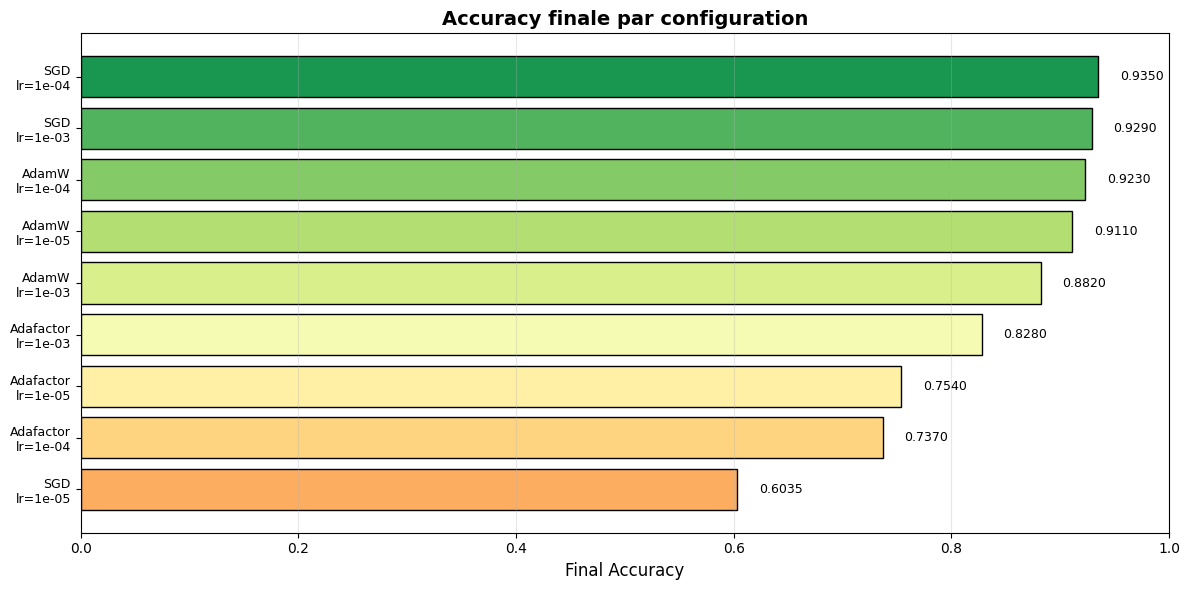

In [5]:
if 'df' in locals():
    fig, ax = plt.subplots(figsize=(12, 6))
    
    df_sorted = df.sort_values('Final Accuracy', ascending=True)
    colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(df_sorted)))
    
    config_names = [f"{row['Optimizer']}\nlr={row['Learning Rate']:.0e}" 
                    for _, row in df_sorted.iterrows()]
    
    ax.barh(range(len(df_sorted)), df_sorted['Final Accuracy'], color=colors, edgecolor='black')
    ax.set_yticks(range(len(df_sorted)))
    ax.set_yticklabels(config_names, fontsize=9)
    ax.set_xlabel('Final Accuracy', fontsize=12)
    ax.set_title('Accuracy finale par configuration', fontsize=14, fontweight='bold')
    ax.set_xlim([0, 1])
    ax.grid(True, alpha=0.3, axis='x')
    
    # Ajouter les valeurs
    for i, (idx, row) in enumerate(df_sorted.iterrows()):
        ax.text(row['Final Accuracy'] + 0.02, i, f"{row['Final Accuracy']:.4f}", 
               va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()

## Graphique: Comparaison Loss vs Accuracy

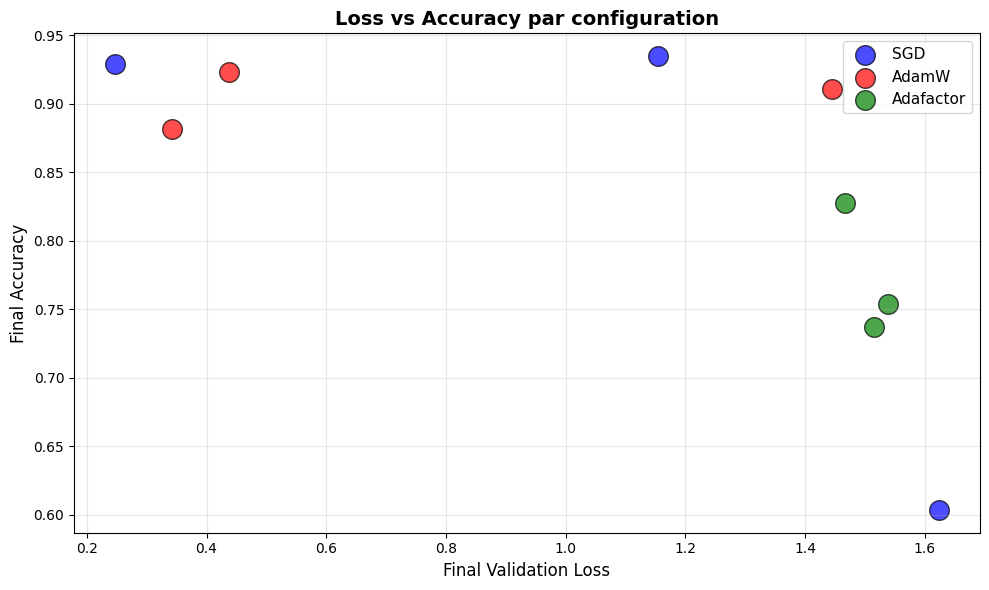

In [6]:
if 'df' in locals():
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Scatter plot
    optimizers = df['Optimizer'].unique()
    colors_map = {'AdamW': 'red', 'SGD': 'blue', 'Adafactor': 'green'}
    
    for opt in optimizers:
        subset = df[df['Optimizer'] == opt]
        ax.scatter(subset['Final Loss'], subset['Final Accuracy'], 
                  s=200, label=opt, color=colors_map[opt], alpha=0.7, edgecolors='black')
    
    ax.set_xlabel('Final Validation Loss', fontsize=12)
    ax.set_ylabel('Final Accuracy', fontsize=12)
    ax.set_title('Loss vs Accuracy par configuration', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## Analyse des courbes de training

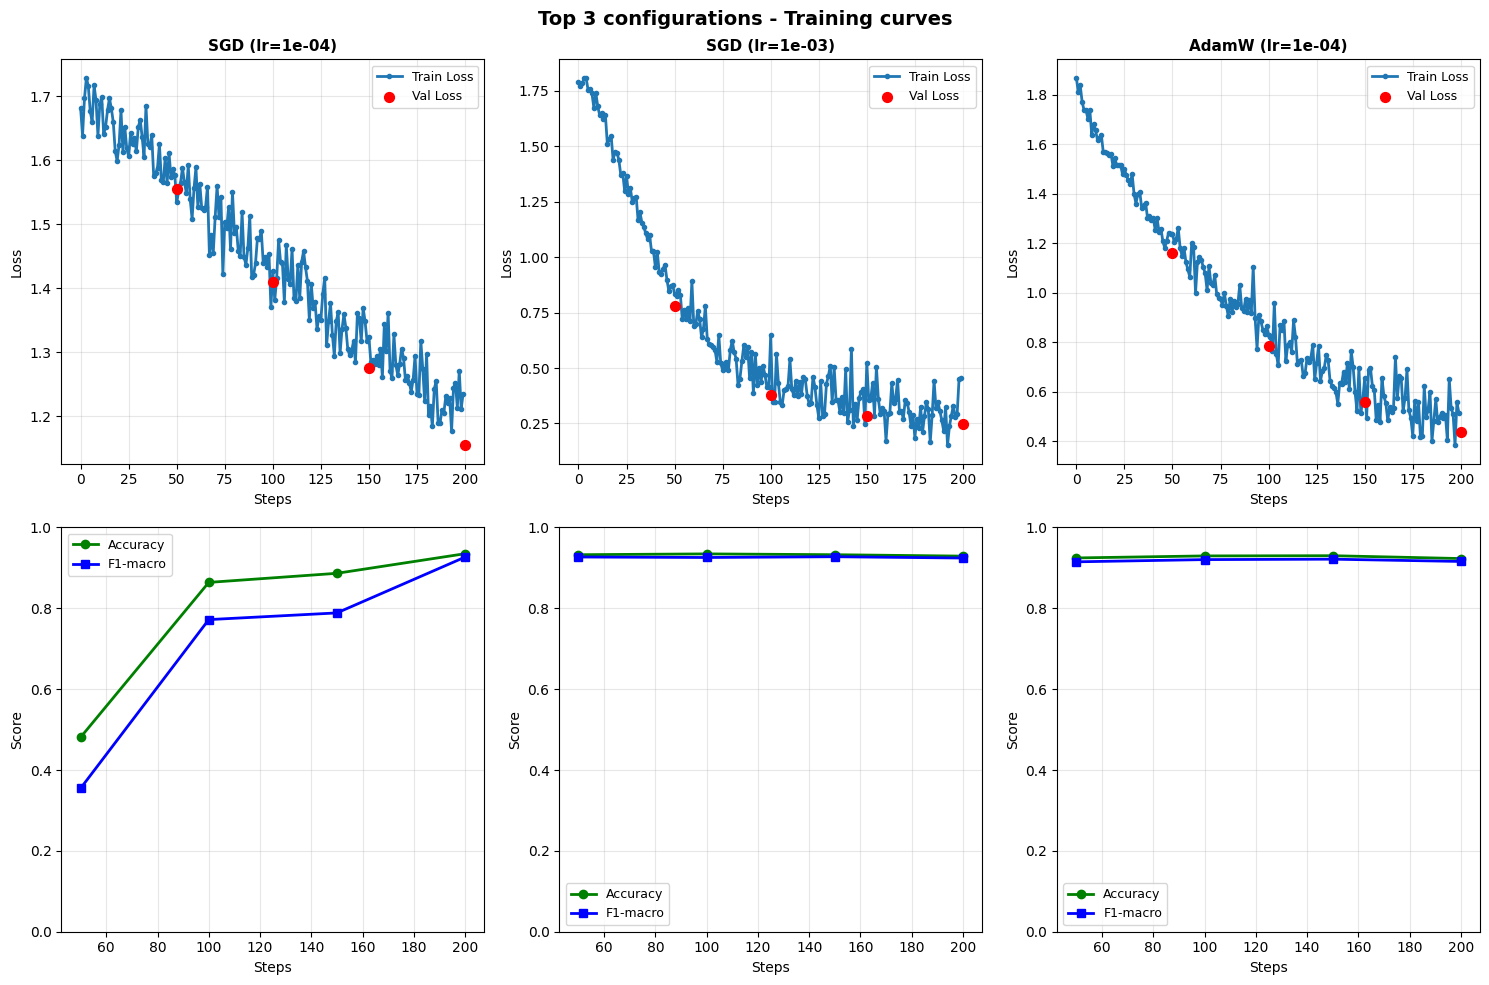

In [7]:
if 'results_data' in locals():
    # Prendre les 3 meilleures configurations
    results = results_data['results']
    sorted_results = sorted(results, key=lambda x: x['final_accuracy'], reverse=True)
    top_3 = sorted_results[:3]
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    for idx, result in enumerate(top_3):
        history = result['history']
        
        # Loss curve
        axes[0, idx].plot(history['train_loss'], label='Train Loss', linewidth=2, marker='o', markersize=3)
        if history['steps']:
            axes[0, idx].scatter(history['steps'], history['val_loss'], 
                               color='red', s=50, label='Val Loss', zorder=5)
        axes[0, idx].set_title(f"{result['optimizer']} (lr={result['learning_rate']:.0e})", fontsize=11, fontweight='bold')
        axes[0, idx].set_xlabel('Steps')
        axes[0, idx].set_ylabel('Loss')
        axes[0, idx].legend(fontsize=9)
        axes[0, idx].grid(True, alpha=0.3)
        
        # Accuracy curve
        if history['steps']:
            axes[1, idx].plot(history['steps'], history['accuracy'], label='Accuracy', 
                             linewidth=2, marker='o', markersize=6, color='green')
            axes[1, idx].plot(history['steps'], history['f1_macro'], label='F1-macro', 
                             linewidth=2, marker='s', markersize=6, color='blue')
        axes[1, idx].set_xlabel('Steps')
        axes[1, idx].set_ylabel('Score')
        axes[1, idx].set_ylim([0, 1])
        axes[1, idx].legend(fontsize=9)
        axes[1, idx].grid(True, alpha=0.3)
    
    fig.suptitle('Top 3 configurations - Training curves', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Résumé des findings

In [ ]:
if 'df' in locals() and 'results_data' in locals():
    best_result = df.iloc[0]
    worst_result = df.iloc[-1]
    
    print("="*70)
    print("RÉSUMÉ FINAL")
    print("="*70)
    
    print(f"\n MEILLEURE CONFIGURATION:")
    print(f"   Optimizer: {best_result['Optimizer']}")
    print(f"   Learning Rate: {best_result['Learning Rate']:.0e}")
    print(f"   Final Accuracy: {best_result['Final Accuracy']:.4f}")
    print(f"   Final F1-macro: {best_result['Final F1-macro']:.4f}")
    print(f"   Final Loss: {best_result['Final Loss']:.4f}")
    
    print(f"\n PIRE CONFIGURATION:")
    print(f"   Optimizer: {worst_result['Optimizer']}")
    print(f"   Learning Rate: {worst_result['Learning Rate']:.0e}")
    print(f"   Final Accuracy: {worst_result['Final Accuracy']:.4f}")
    
    print(f"\n STATISTIQUES GLOBALES:")
    print(f"   Accuracy moyenne: {df['Final Accuracy'].mean():.4f}")
    print(f"   Accuracy écart-type: {df['Final Accuracy'].std():.4f}")
    print(f"   Accuracy min-max: [{df['Final Accuracy'].min():.4f}, {df['Final Accuracy'].max():.4f}]")
    
    print(f"\n OBSERVATIONS:")
    
    # Observer les learning rates
    for opt in df['Optimizer'].unique():
        subset = df[df['Optimizer'] == opt].sort_values('Learning Rate')
        lrs = subset['Learning Rate'].values
        accs = subset['Final Accuracy'].values
        
        best_lr = lrs[np.argmax(accs)]
        print(f"   - {opt}: Meilleur learning rate = {best_lr:.0e}")
    
    print(f"\n" + "="*70)

RÉSUMÉ FINAL

🏆 MEILLEURE CONFIGURATION:
   Optimizer: SGD
   Learning Rate: 1e-04
   Final Accuracy: 0.9350
   Final F1-macro: 0.9266
   Final Loss: 1.1550

⚠️ PIRE CONFIGURATION:
   Optimizer: SGD
   Learning Rate: 1e-05
   Final Accuracy: 0.6035

📊 STATISTIQUES GLOBALES:
   Accuracy moyenne: 0.8336
   Accuracy écart-type: 0.1142
   Accuracy min-max: [0.6035, 0.9350]

💡 OBSERVATIONS:
   - SGD: Meilleur learning rate = 1e-04
   - AdamW: Meilleur learning rate = 1e-04
   - Adafactor: Meilleur learning rate = 1e-03

